# 1
- pure comp: molecular
- kij: molecular
- melting: molecular

In [1]:
using Pkg, Revise
using Clapeyron, PyCall
import PyPlot; const plt = PyPlot
import DataFrames

In [3]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter1 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_held,75.07,4.8495,2.3270,216.9600,2,2
metanol,32.04,1.5255,3.2300,188.90,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter1 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
metanol,glycine_held,-0.011
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter1 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
metanol,H,metanol,e,2899.5,0.035176
glycine_held,H,glycine_held,e,2598.06,0.0393 
metanol,H,glycine_held,e,2748.78,0.035718
metanol,e,glycine_held,H,2748.78,0.035718
"""
components = ["metanol", "glycine_held"]
model1 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter1, unlike_parameter1, assoc_parameter1])

println(model1.fluid.params.epsilon.values)
println(model1.fluid.params.sigma.values)
println("======================")
println(model1.fluid.params.epsilon_assoc.values)
println(model1.fluid.params.bondvol.values)
println("kij = ", (1  - ((model1.fluid.params.epsilon.values[2])/(sqrt(model1.fluid.params.epsilon.values[1] * model1.fluid.params.epsilon.values[4])))))
println("Hfus = ", model1.solid.params.Hfus[2])
println("Tm = ", model1.solid.params.Tm[2])

[188.9 204.6713106447115; 204.6713106447115 216.96]
[3.23e-10 2.7785000000000003e-10; 2.7785000000000003e-10 2.327e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2899.5, 2748.78, 2748.78, 2598.06]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.035176, 0.035718, 0.035718, 0.0393]
kij = -0.010999999999999899
Hfus = 17536.72
Tm = 714.3



=== HASIL PERHITUNGAN MODEL ===
25×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0           0.00069776
   2 │      288.512         0.00147121
   3 │      307.025         0.00282795
   4 │      325.538         0.0050445
   5 │      344.05          0.00846609
   6 │      362.562         0.0135119
   7 │      381.075         0.0206809
   8 │      399.587         0.0305566
   9 │      418.1           0.0438114
  10 │      436.612         0.0612074
  11 │      455.125         0.0835948
  12 │      473.638         0.111904
  13 │      492.15        NaN
  14 │      510.662       NaN
  15 │      529.175       NaN
  16 │      547.688         0.300211
  17 │      566.2           0.364058
  18 │      584.712         0.424475
  19 │      603.225         0.510773
  20 │      621.737         0.599694
  21 │      640.25          0.74105
  22 │      658.762         0.883116
  23 │      677.275      

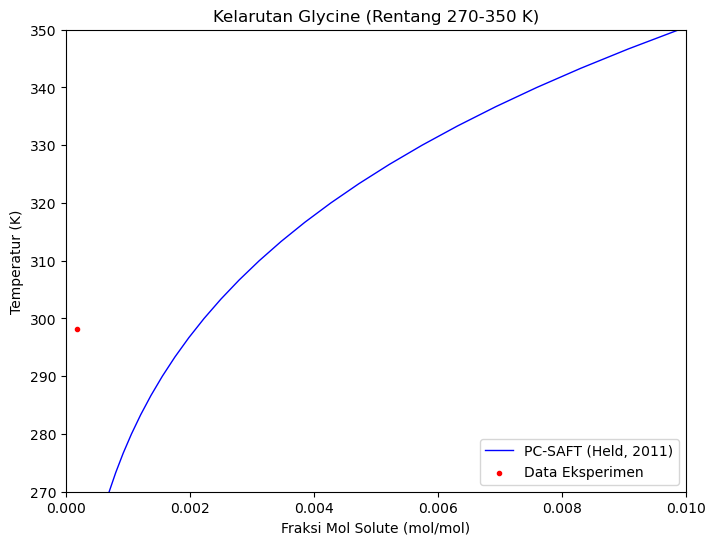

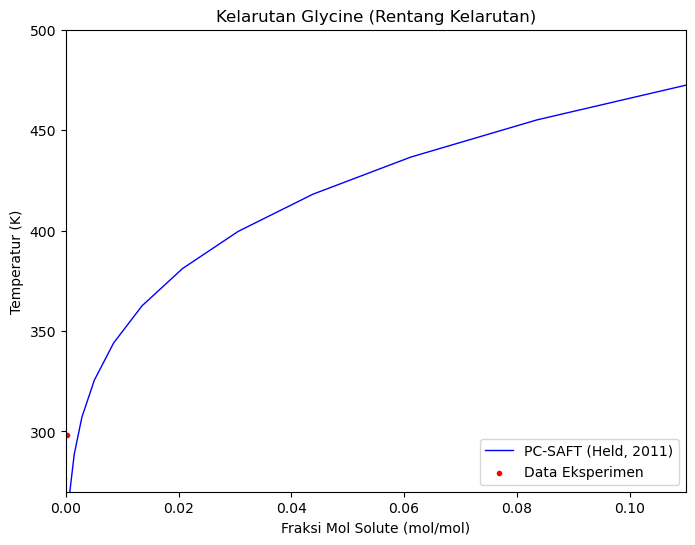

In [6]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_metanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.01)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_T_glycine_metanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270.,model1.solid.params.Tm[2], 25)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.11)
    plt.ylim(270.0, 500.)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_x_glycine_metanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [7]:
using CSV, DataFrames, Printf

function solubility_gclow(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_gclow"])[2]
    return x2
end

function solubility_gcmid(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_gcmid"])[2]
    return x2
end

function solubility_gcup(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_gcup"])[2]
    return x2
end

function solubility_held(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["glycine_held"])[2]
    return x2
end

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [8]:
aard_p   = calculate_AAD(model1, "sol_glycine_metanol.csv", solubility_held)


=== AAD: sol_glycine_metanol.csv ===


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.002089      1107.3931
AARD = 1107.3931%


1107.3930546534966

# 2
- pure comp: GC
- kij: GC
- melting: GC

In [9]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter2 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
metanol,32.04,1.5255,3.2300,188.90,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter2 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
metanol,glycine_gclow,0.265243
metanol,glycine_gcmid,0.265243
metanol,glycine_gcup,0.265243
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter2 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
metanol,H,metanol,e,2899.5,0.035176
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
metanol,H,glycine_gclow,e,2955.809,0.091904
metanol,e,glycine_gclow,H,2955.809,0.091904
metanol,H,glycine_gcmid,e,2955.809,0.091904
metanol,e,glycine_gcmid,H,2955.809,0.091904
metanol,H,glycine_gcup,e,2955.809,0.091904
metanol,e,glycine_gcup,H,2955.809,0.091904
"""
components_low = ["metanol", "glycine_gclow"]
components_mid = ["metanol", "glycine_gcmid"]
components_up = ["metanol", "glycine_gcup"]

model2_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])


println("low bound")
println("Hfus = ", model2_low.solid.params.Hfus[2])
println("Tm = ", model2_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model2_mid.solid.params.Hfus[2])
println("Tm = ", model2_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model2_up.solid.params.Hfus[2])
println("Tm = ", model2_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    3.83743e-7   9.52783e-8   2.14104e-8
   2 │      276.498  6.93083e-7   1.80681e-7   4.26306e-8
   3 │      282.997  1.21571e-6   3.32015e-7   8.20671e-8
   4 │      289.495  2.07525e-6   5.92503e-7   1.53108e-7
   5 │      295.993  3.45403e-6   1.02893e-6   2.77421e-7
   6 │      302.492  5.61486e-6   1.74198e-6   4.89158e-7
   7 │      308.99   8.92872e-6   2.87997e-6   8.40818e-7
   8 │      315.489  1.39091e-5   4.6568e-6    1.41126e-6
   9 │      321.987  2.12539e-5   7.37481e-6   2.31643e-6
  10 │      328.485  3.18956e-5   1.14535e-5   3.72332e-6
  11 │      334.984  4.70607e-5   1.74647e-5   5.868e-6
  12 │      341.482  6.83392e-5   2.61755e-5   9.07826e-6
  13 │      347.981  9.77631e-5   3.85992e-5   1.38017e-5
  14 │      354.479 

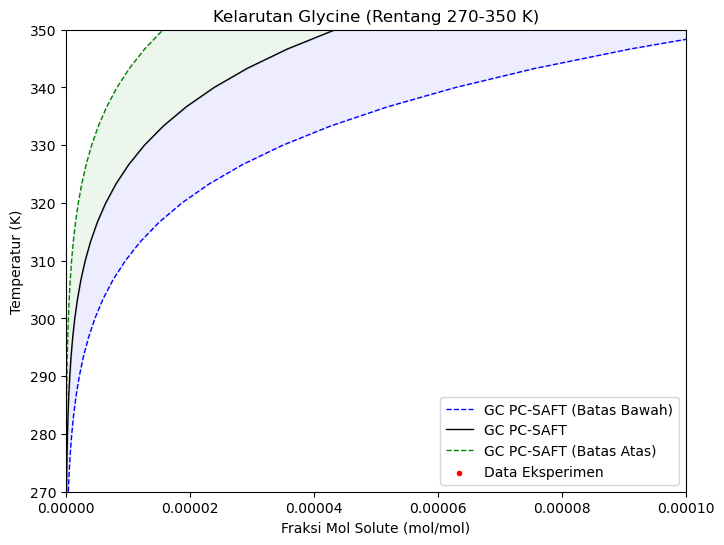

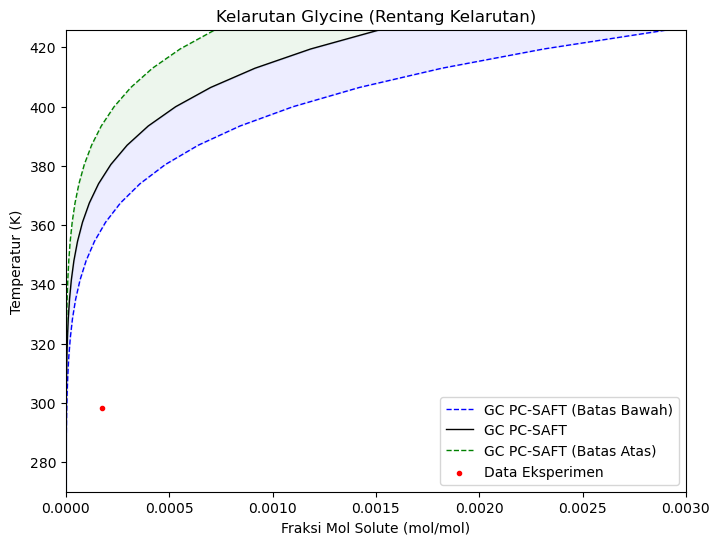

In [12]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_metanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.0001)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_T_glycine_metanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model2_low.solid.params.Tm[2], 25)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.003)
    plt.ylim(270.0, model2_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_x_glycine_metanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [13]:
aard_p   = calculate_AAD(model2_low, "sol_glycine_metanol.csv", solubility_gclow)


=== AAD: sol_glycine_metanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.000004      97.6482 
AARD = 97.6482%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


97.64817099646314

In [14]:
aard_p   = calculate_AAD(model2_mid, "sol_glycine_metanol.csv", solubility_gcmid)


=== AAD: sol_glycine_metanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.000001      99.2898 
AARD = 99.2898%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.28975618792161

In [15]:
aard_p   = calculate_AAD(model2_up, "sol_glycine_metanol.csv", solubility_gcup)


=== AAD: sol_glycine_metanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.000000      99.8059 
AARD = 99.8059%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.80586474404272

# 3
- pure comp: GC
- kij: GC
- melting: molecular

In [16]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter3 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_held,75.07,4.8492,2.2140,238.6085,2,2 
metanol,32.04,1.5255,3.2300,188.90,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter3 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
metanol,glycine_held,0.265243
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter3 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
metanol,H,metanol,e,2899.5,0.035176
glycine_held,H,glycine_held,e,3012.118,0.267058
metanol,H,glycine_held,e,2955.809,0.091904
metanol,e,glycine_held,H,2955.809,0.091904
"""
components = ["metanol", "glycine_held"]
model3 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter3, unlike_parameter3, assoc_parameter3])

println(model3.fluid.params.epsilon.values)
println(model3.fluid.params.sigma.values)
println("======================")
println(model3.fluid.params.epsilon_assoc.values)
println(model3.fluid.params.bondvol.values)
println("kij = ", (1  - ((model3.fluid.params.epsilon.values[2])/(sqrt(model3.fluid.params.epsilon.values[1] * model3.fluid.params.epsilon.values[4])))))
println("Hfus = ", model3.solid.params.Hfus[2])
println("Tm = ", model3.solid.params.Tm[2])

[188.9 155.9921222111482; 155.9921222111482 238.6085]
[3.23e-10 2.722e-10; 2.722e-10 2.214e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2899.5, 2955.809, 2955.809, 3012.118]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.035176, 0.091904, 0.091904, 0.267058]
kij = 0.2652429999999999
Hfus = 17536.72
Tm = 714.3



=== HASIL PERHITUNGAN MODEL ===
25×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0          1.43066e-7
   2 │      279.583        3.0797e-7
   3 │      289.167        6.27355e-7
   4 │      298.75         1.21613e-6
   5 │      308.333        2.25437e-6
   6 │      317.917        4.01322e-6
   7 │      327.5          6.88652e-6
   8 │      337.083        1.1428e-5
   9 │      346.667        1.8393e-5
  10 │      356.25         2.87842e-5
  11 │      365.833        4.38986e-5
  12 │      375.417        6.53729e-5
  13 │      385.0          9.52247e-5
  14 │      394.583        0.000135881
  15 │      404.167        0.000190188
  16 │      413.75         0.000261384
  17 │      423.333        0.000353015
  18 │      432.917        0.00046874
  19 │      442.5          0.000611934
  20 │      452.083        0.000784866
  21 │      461.667        0.000986823
  22 │      471.25         0.0

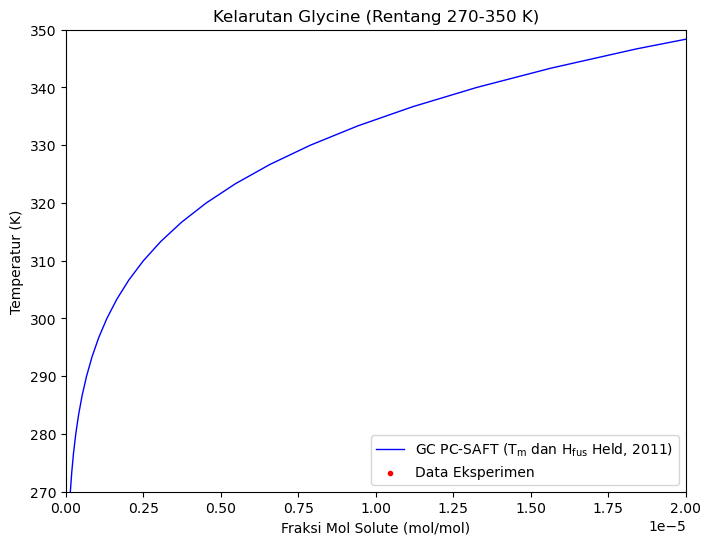

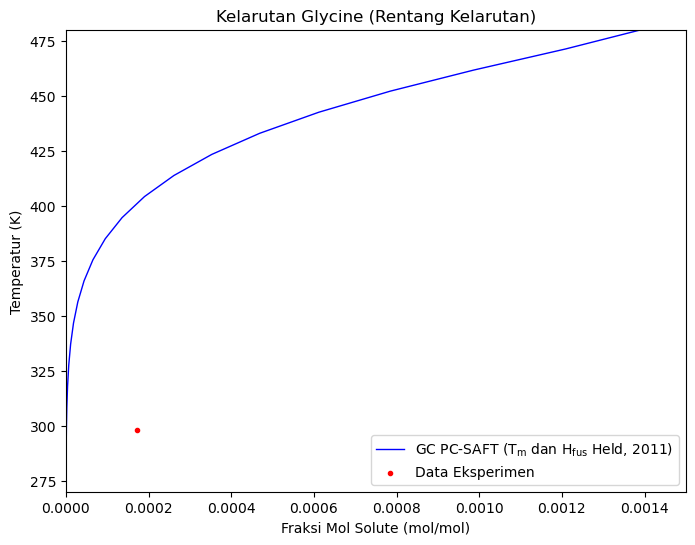

In [19]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_glycine_metanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label = "Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 2e-5)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_T_glycine_metanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., 500., 25)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["glycine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label = "Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.0015)
    plt.ylim(270.0, 480.)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_x_glycine_metanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [20]:
aard_p   = calculate_AAD(model3, "sol_glycine_metanol.csv", solubility_held)


=== AAD: sol_glycine_metanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.000001      99.3247 
AARD = 99.3247%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.32465168117565

# 4
- pure comp: GC
- kij: molecular
- melting: GC

In [21]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter4 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
metanol,32.04,1.5255,3.2300,188.90,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter4 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
metanol,glycine_gclow,-0.011
metanol,glycine_gcmid,-0.011
metanol,glycine_gcup,-0.011
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter4 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
metanol,H,metanol,e,2899.5,0.035176
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
metanol,H,glycine_gclow,e,2955.809,0.091904
metanol,e,glycine_gclow,H,2955.809,0.091904
metanol,H,glycine_gcmid,e,2955.809,0.091904
metanol,e,glycine_gcmid,H,2955.809,0.091904
metanol,H,glycine_gcup,e,2955.809,0.091904
metanol,e,glycine_gcup,H,2955.809,0.091904
"""
components_low = ["metanol", "glycine_gclow"]
components_mid = ["metanol", "glycine_gcmid"]
components_up = ["metanol", "glycine_gcup"]

model4_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])


println("low bound")
println("Hfus = ", model4_low.solid.params.Hfus[2])
println("Tm = ", model4_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model4_mid.solid.params.Hfus[2])
println("Tm = ", model4_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model4_up.solid.params.Hfus[2])
println("Tm = ", model4_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    0.000384646  9.515e-5     2.13615e-5
   2 │      276.498  0.000560517  0.00014537   3.42516e-5
   3 │      282.997  0.000801394  0.000217318  5.36097e-5
   4 │      289.495  0.00112588   0.000318388  8.20436e-5
   5 │      295.993  0.00155648   0.000457805  0.000122955
   6 │      302.492  0.00212025   0.000646915  0.000180698
   7 │      308.99   0.00284959   0.000899488  0.000260747
   8 │      315.489  0.00378331   0.00123206   0.000369881
   9 │      321.987  0.00496811   0.00166431   0.00051636
  10 │      328.485  0.00646066   0.00221951   0.000710127
  11 │      334.984  0.00833075   0.0029251    0.000962998
  12 │      341.482  0.010666     0.00381342   0.00128887
  13 │      347.981  0.0135794    0.00492266   0.00170396
  14 │      

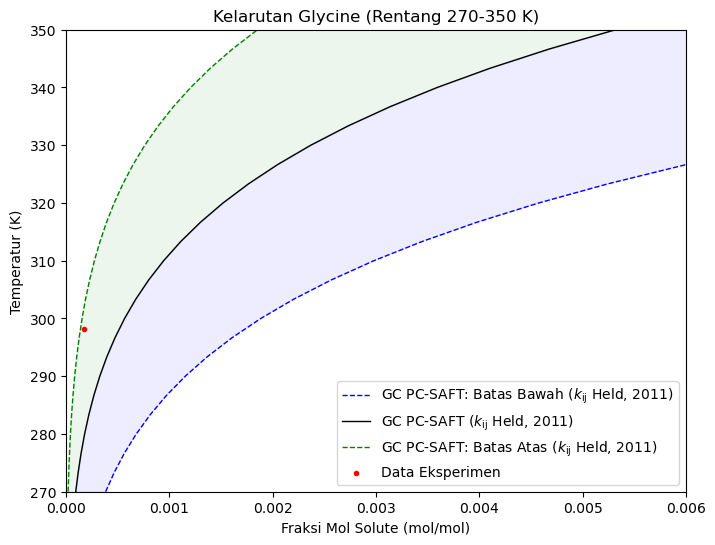

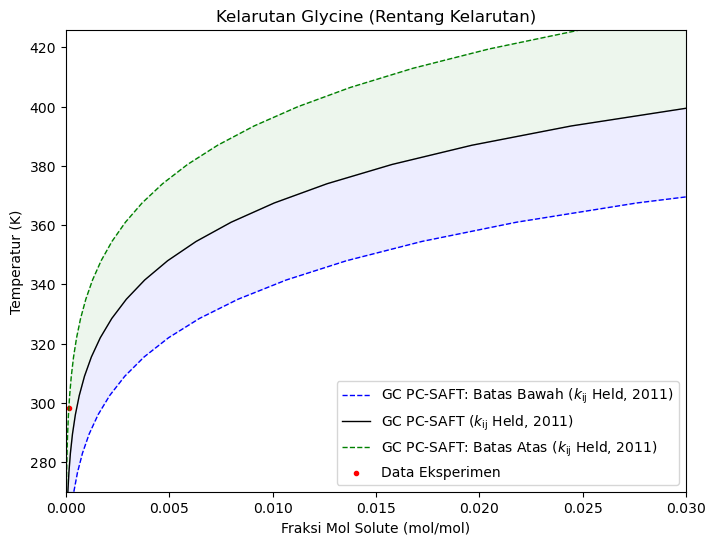

In [22]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_glycine_metanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.006)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_T_glycine_metanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model4_low.solid.params.Tm[2], 25)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.03)
    plt.ylim(270.0, model4_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_x_glycine_metanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [23]:
aard_p   = calculate_AAD(model4_low, "sol_glycine_metanol.csv", solubility_gclow)


=== AAD: sol_glycine_metanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.001727      898.4563
AARD = 898.4563%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


898.456279483643

In [24]:
aard_p   = calculate_AAD(model4_mid, "sol_glycine_metanol.csv", solubility_gcmid)


=== AAD: sol_glycine_metanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.000514      197.3570
AARD = 197.3570%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


197.35696066617942

In [25]:
aard_p   = calculate_AAD(model4_up, "sol_glycine_metanol.csv", solubility_gcup)


=== AAD: sol_glycine_metanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.000140      19.0715 
AARD = 19.0715%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


19.07152654335212

# 5
- pure comp: GC
- kij: 0
- melting: GC

In [26]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter5 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
metanol,32.04,1.5255,3.2300,188.90,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter5 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
metanol,glycine_gclow,0
metanol,glycine_gcmid,0
metanol,glycine_gcup,0
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter5 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
metanol,H,metanol,e,2899.5,0.035176
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
metanol,H,glycine_gclow,e,2955.809,0.091904
metanol,e,glycine_gclow,H,2955.809,0.091904
metanol,H,glycine_gcmid,e,2955.809,0.091904
metanol,e,glycine_gcmid,H,2955.809,0.091904
metanol,H,glycine_gcup,e,2955.809,0.091904
metanol,e,glycine_gcup,H,2955.809,0.091904
"""
components_low = ["metanol", "glycine_gclow"]
components_mid = ["metanol", "glycine_gcmid"]
components_up = ["metanol", "glycine_gcup"]

model5_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])


println("low bound")
println("Hfus = ", model5_low.solid.params.Hfus[2])
println("Tm = ", model5_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model5_mid.solid.params.Hfus[2])
println("Tm = ", model5_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model5_up.solid.params.Hfus[2])
println("Tm = ", model5_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    0.000291259  7.21073e-5   1.61916e-5
   2 │      276.498  0.000427964  0.000111114  2.61881e-5
   3 │      282.997  0.000616658  0.000167469  4.13295e-5
   4 │      289.495  0.000872674  0.000247263  6.37519e-5
   5 │      295.993  0.00121463   0.000358161  9.62664e-5
   6 │      302.492  0.00166496   0.000509648  0.000142501
   7 │      308.99   0.00225048   0.000713313  0.000207054
   8 │      315.489  0.00300325   0.00098313   0.000295659
   9 │      321.987  0.00396155   0.00133579   0.000415356
  10 │      328.485  0.00517135   0.00179108   0.000574665
  11 │      334.984  0.0066884    0.00237229   0.000783772
  12 │      341.482  0.00858125   0.0031068    0.00105471
  13 │      347.981  0.010936     0.00402681   0.00140156
  14 │      

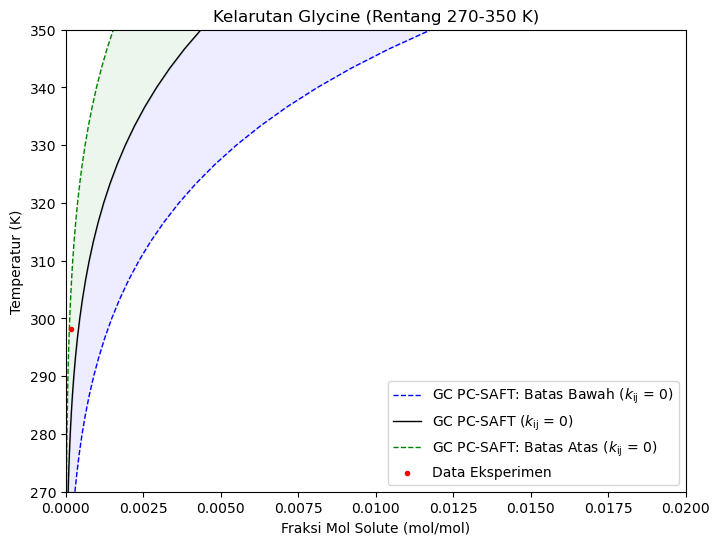

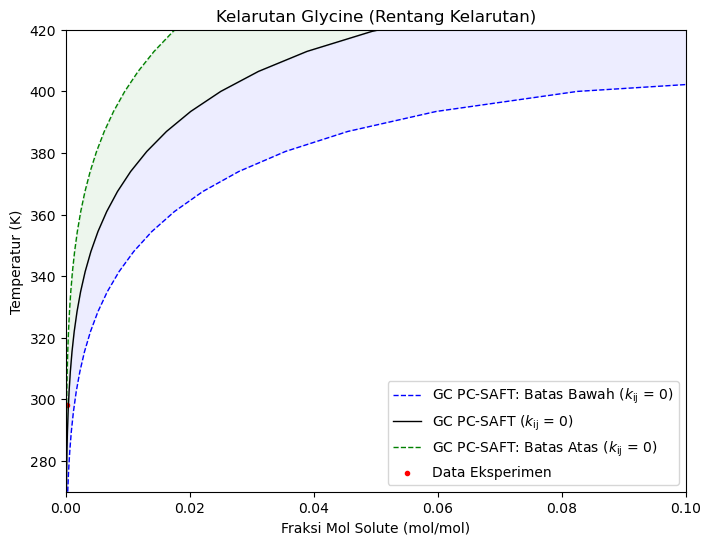

In [27]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_metanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.02)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_T_glycine_metanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model5_low.solid.params.Tm[2], 25)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.1)
    plt.ylim(270.0, 420.)
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_x_glycine_metanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [28]:
aard_p   = calculate_AAD(model5_low, "sol_glycine_metanol.csv", solubility_gclow)


=== AAD: sol_glycine_metanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.001351      680.8301
AARD = 680.8301%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


680.8301237833305

In [29]:
aard_p   = calculate_AAD(model5_mid, "sol_glycine_metanol.csv", solubility_gcmid)


=== AAD: sol_glycine_metanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.000403      133.1836
AARD = 133.1836%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


133.18361006289797

In [30]:
aard_p   = calculate_AAD(model5_up, "sol_glycine_metanol.csv", solubility_gcup)


=== AAD: sol_glycine_metanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.000110      36.4836 
AARD = 36.4836%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


36.48357186804255

# 6
- pure comp: GC
- kij: molecular (VLE GC)
- melting: GC

In [31]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter6 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
metanol,32.04,1.5255,3.2300,188.90,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter6 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
metanol,glycine_gclow,0.147472927
metanol,glycine_gcmid,0.147472927
metanol,glycine_gcup,0.147472927
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter6 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
metanol,H,metanol,e,2899.5,0.035176
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
metanol,H,glycine_gclow,e,2955.809,0.091904
metanol,e,glycine_gclow,H,2955.809,0.091904
metanol,H,glycine_gcmid,e,2955.809,0.091904
metanol,e,glycine_gcmid,H,2955.809,0.091904
metanol,H,glycine_gcup,e,2955.809,0.091904
metanol,e,glycine_gcup,H,2955.809,0.091904
"""
components_low = ["metanol", "glycine_gclow"]
components_mid = ["metanol", "glycine_gcmid"]
components_up = ["metanol", "glycine_gcup"]

model6_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])


println("low bound")
println("Hfus = ", model6_low.solid.params.Hfus[2])
println("Tm = ", model6_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model6_mid.solid.params.Hfus[2])
println("Tm = ", model6_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model6_up.solid.params.Hfus[2])
println("Tm = ", model6_up.solid.params.Tm[2])

low bound
Hfus = 23742.4
Tm = 425.961
mid bound
Hfus = 28400.0
Tm = 462.5
up bound
Hfus = 33057.6
Tm = 499.0358



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    7.19211e-6   1.78553e-6   4.01225e-7
   2 │      276.498  1.18496e-5   3.08863e-6   7.28713e-7
   3 │      282.997  1.9038e-5    5.19813e-6   1.28478e-6
   4 │      289.495  2.98794e-5   8.52787e-6   2.20344e-6
   5 │      295.993  4.58841e-5   1.36616e-5   3.68288e-6
   6 │      302.492  6.90449e-5   2.14054e-5   6.00935e-6
   7 │      308.99   0.000101946  3.28496e-5   9.5873e-6
   8 │      315.489  0.000147882  4.94428e-5   1.49766e-5
   9 │      321.987  0.000210993  7.3075e-5    2.29373e-5
  10 │      328.485  0.000296407  0.000106173  3.44828e-5
  11 │      334.984  0.000410398  0.000151807  5.09413e-5
  12 │      341.482  0.000560556  0.000213803  7.4026e-5
  13 │      347.981  0.000755964  0.00029687   0.000105913
  14 │      354.479

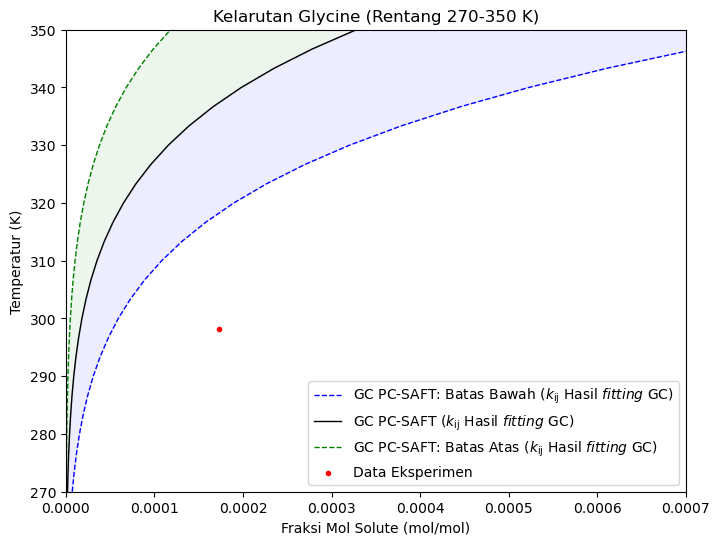

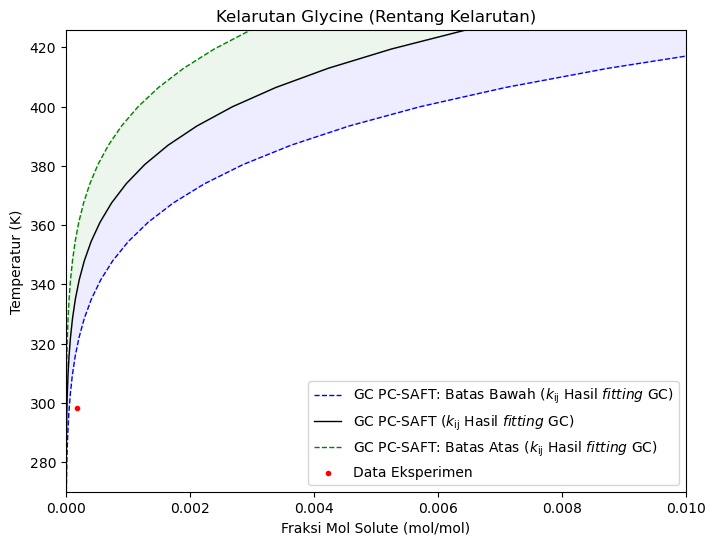

In [35]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_metanol.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 25)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.0007)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_T_glycine_metanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model6_low.solid.params.Tm[2], 25)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["glycine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["glycine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["glycine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.01)
    plt.ylim(270.0, model6_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_x_glycine_metanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [34]:
aard_p   = calculate_AAD(model6_low, "sol_glycine_metanol.csv", solubility_gclow)


=== AAD: sol_glycine_metanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.000053      69.5591 
AARD = 69.5591%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


69.55910653657097

In [36]:
aard_p   = calculate_AAD(model6_mid, "sol_glycine_metanol.csv", solubility_gcmid)


=== AAD: sol_glycine_metanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.000016      90.8122 
AARD = 90.8122%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


90.81220995874773

In [37]:
aard_p   = calculate_AAD(model6_up, "sol_glycine_metanol.csv", solubility_gcup)


=== AAD: sol_glycine_metanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
298.1500    0.000173      0.000004      97.4891 
AARD = 97.4891%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


97.48909611072783